# K-Means — Attrition Clustering

## K-Means Implementation (From Scratch)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import uniform
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix as cm_func, silhouette_score

In [2]:
# Euclidean distance
def euclidean(point, centroid):
    return np.sqrt(np.sum((point - centroid) ** 2))

# Initialize centroids
def init_centroids(X, n_clusters, random_state=42):
    np.random.seed(random_state)
    minpoint, maxpoint = np.min(X, axis=0), np.max(X, axis=0)
    centroids = np.array([uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)])
    return centroids

def calculateClass(X, centroids, n_clusters):
    sorted_x = [[] for _ in range(n_clusters)]
    labels = np.zeros(len(X), dtype=int)
    for idx, x in enumerate(X):
        dists = [euclidean(x, centroid) for centroid in centroids]
        centroid_idx = np.argmin(dists)
        sorted_x[centroid_idx].append(x)
        labels[idx] = centroid_idx
    sorted_x = [np.array(cluster) if len(cluster) > 0 else np.empty((0, X.shape[1])) for cluster in sorted_x]
    return sorted_x, labels

# After that, we use the result to adjust the current centroid.
# Reassign centroids as the mean of the points belonging to them.
def adjustCentroid(sorted_x, centroids):
    prev_centroids = centroids
    new_centroids = []
    for i, cluster in enumerate(sorted_x):
        if len(cluster) > 0:
            new_centroids.append(np.mean(cluster, axis=0))
        else:
            new_centroids.append(prev_centroids[i])
    return np.array(new_centroids)

'''
Training loop: 
    1. calculateClasses
    2. adjustCentroid
    3. repeat until converged
''' 
def train(X, n_clusters, max_iters=300, random_state=42):
    centroids = init_centroids(X, n_clusters, random_state)
    labels = None
    for iteration in range(max_iters):
        sorted_x, labels = calculateClass(X, centroids, n_clusters)
        new_centroids = adjustCentroid(sorted_x, centroids)
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {iteration + 1}")
            break
        centroids = new_centroids
    else:
        print(f"Reached max iterations ({max_iters})")

    inertia = sum(euclidean(X[i], centroids[labels[i]])**2 for i in range(len(X)))
    return centroids, labels, sorted_x, inertia

# Plotting
def showplotwithclass_2d(sorted_x_2d, centroids_2d, title="K-Means Clusters"):
    plt.figure(figsize=(9, 3.5))
    colors = plt.cm.tab20.colors
    for i, cluster_points in enumerate(sorted_x_2d):
        if len(cluster_points) == 0:
            continue
        cluster_points = np.array(cluster_points)
        plt.plot(cluster_points[:, 0], cluster_points[:, 1],
                 marker='o', linestyle='', color=colors[i % len(colors)],
                 label=f"Cluster {i}")
    centroids_arr = np.array(centroids_2d)
    plt.plot(centroids_arr[:, 0], centroids_arr[:, 1],
             'k+', markersize=15, markeredgewidth=3, label="Centroids")
    plt.xlabel("Component 1", fontsize=10)
    plt.ylabel("Component 2", fontsize=10)
    plt.title(title, fontsize=12)
    plt.legend(fontsize=10)
    plt.show()

## Load & Prepare Data

In [3]:
df = pd.read_csv('../data/processed_data.csv')

# Separate features and Attrition
attrition_raw = df['Attrition'].values
attrition_binary = (attrition_raw == attrition_raw.max()).astype(int)
X = df.drop(columns=['Attrition']).values
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"Dataset shape: {X.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"\nAttrition distribution — real data (NOT used in clustering):")
print(f"  No Attrition (0): {np.sum(attrition_binary == 0)}")
print(f"  Attrition    (1): {np.sum(attrition_binary == 1)}")


Dataset shape: (1470, 36)
Features (36): ['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'PerformanceIndex', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyAchievement', 'NumCompaniesWorked', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'RemoteWork', 'MonthlyIncome', 'WelfareBenefits', 'InHouseFacility', 'ExternalFacility', 'ExtendedLeave', 'FlexibleWork', 'StressSelfReported', 'StressRating']

Attrition distribution — real data (NOT used in clustering):
  No Attrition (0): 1232
  Attrition    (1): 238


## Run K-Means

In [4]:
centroids, labels, sorted_x, inertia = train(X, n_clusters=2, random_state=42)

print(f"\nK-Means Clustering with K=2")
print(f"Inertia (WCSS): {inertia:.2f}")
print(f"\nCluster distribution:")
for k in range(2):
    count = np.sum(labels == k)
    print(f"  Cluster {k}: {count} samples ({count/len(labels)*100:.1f}%)")

Converged at iteration 11

K-Means Clustering with K=2
Inertia (WCSS): 47987.77

Cluster distribution:
  Cluster 0: 807 samples (54.9%)
  Cluster 1: 663 samples (45.1%)


## Evaluation on Test Set

In [5]:
def map_clusters_to_labels(cluster_labels, true_labels):
    acc_1 = np.mean(cluster_labels == true_labels)
    flipped = 1 - cluster_labels
    acc_2 = np.mean(flipped == true_labels)
    if acc_2 > acc_1:
        return flipped, acc_2
    return cluster_labels, acc_1

predicted, accuracy = map_clusters_to_labels(labels, attrition_binary)

# Confusion Matrix
tp = np.sum((predicted == 1) & (attrition_binary == 1))
tn = np.sum((predicted == 0) & (attrition_binary == 0))
fp = np.sum((predicted == 1) & (attrition_binary == 0))
fn = np.sum((predicted == 0) & (attrition_binary == 1))

# Precision, Sensitivity, Specificity, True Negative Rate, F1-score, Silhouette Score
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
sil_score = silhouette_score(X, labels)

print("=" * 45)
print("  K-Means (K=2) — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:        {accuracy:.4f}")
print(f"  Precision:       {precision:.4f}")
print(f"  Recall:          {recall:.4f}")
print(f"  Specificity:     {specificity:.4f}")
print(f"  F1 Score:        {f1:.4f}")
print(f"  Inertia (WCSS):  {inertia:.2f}")
print(f"  Silhouette Score:{sil_score:.4f}")
print("=" * 45)
print(f"\n  Confusion Matrix:")
print(f"                Predicted")
print(f"                No(0)  Yes(1)")
print(f"  Actual No(0)  {tn:<6} {fp}")
print(f"  Actual Yes(1) {fn:<6} {tp}")

print(f"\n  Attrition Rate per Cluster:")
for k in range(2):
    cluster_mask = labels == k
    attrition_rate = np.mean(attrition_binary[cluster_mask]) * 100
    print(f"    Cluster {k}: {attrition_rate:.1f}% attrition "
          f"({np.sum(attrition_binary[cluster_mask])}/{np.sum(cluster_mask)} employees)")

  K-Means (K=2) — Evaluation Results
  Accuracy:        0.5109
  Precision:       0.2020
  Recall:          0.6849
  Specificity:     0.4773
  F1 Score:        0.3120
  Inertia (WCSS):  47987.77
  Silhouette Score:0.0912

  Confusion Matrix:
                Predicted
                No(0)  Yes(1)
  Actual No(0)  588    644
  Actual Yes(1) 75     163

  Attrition Rate per Cluster:
    Cluster 0: 20.2% attrition (163/807 employees)
    Cluster 1: 11.3% attrition (75/663 employees)


## Confusion Matrix

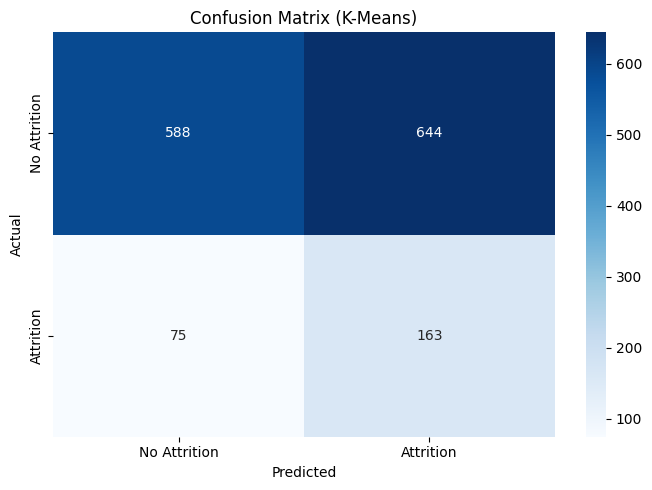

In [6]:
cm_kmeans = cm_func(attrition_binary, predicted)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (K-Means)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Cluster Visualization (PCA 2D)

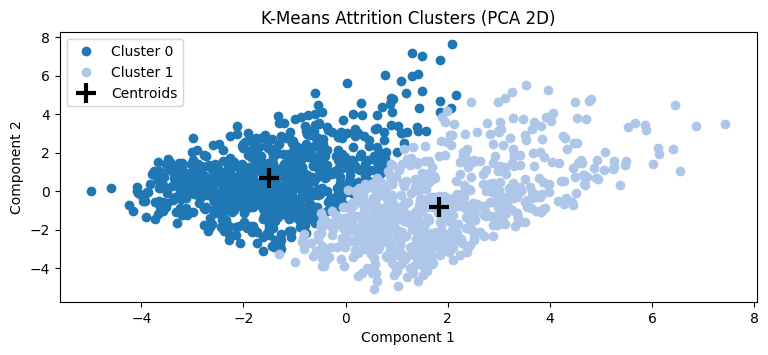

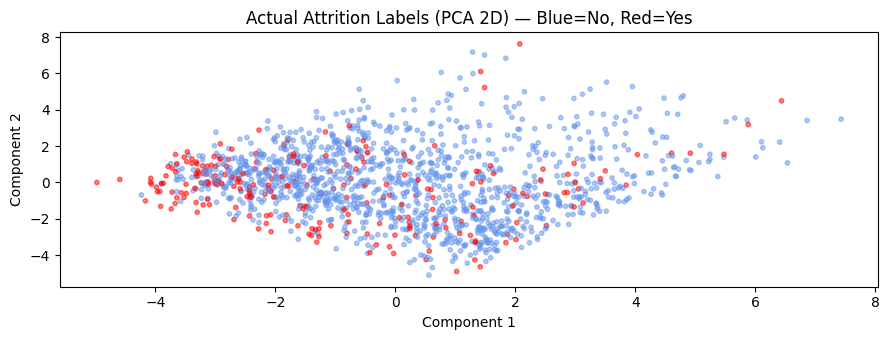


PCA explained variance: 23.3%


In [7]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
centroids_2d = pca.transform(centroids)
sorted_x_2d = [X_2d[labels == k] for k in range(2)]
showplotwithclass_2d(sorted_x_2d, centroids_2d, title="K-Means Attrition Clusters (PCA 2D)")

# Plot actual attrition for comparison
plt.figure(figsize=(9, 3.5))
colors_actual = ['cornflowerblue' if y == 0 else 'red' for y in attrition_binary]
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_actual, alpha=0.5, s=10)
plt.xlabel("Component 1", fontsize=10)
plt.ylabel("Component 2", fontsize=10)
plt.title("Actual Attrition Labels (PCA 2D) — Blue=No, Red=Yes", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

---
# Sklearn K-Means — Comparison

In [8]:
sklearn_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
sklearn_labels = sklearn_kmeans.fit_predict(X)
sklearn_pred, sklearn_acc = map_clusters_to_labels(sklearn_labels, attrition_binary)

# Confusion Matrix
tp_sk = np.sum((sklearn_pred == 1) & (attrition_binary == 1))
tn_sk = np.sum((sklearn_pred == 0) & (attrition_binary == 0))
fp_sk = np.sum((sklearn_pred == 1) & (attrition_binary == 0))
fn_sk = np.sum((sklearn_pred == 0) & (attrition_binary == 1))

# Precision, Sensitivity, Specificity, True Negative Rate, F1-score, Silhouette Score
prec_sk = tp_sk / (tp_sk + fp_sk) if (tp_sk + fp_sk) > 0 else 0
rec_sk = tp_sk / (tp_sk + fn_sk) if (tp_sk + fn_sk) > 0 else 0
spec_sk = tn_sk / (tn_sk + fp_sk) if (tn_sk + fp_sk) > 0 else 0
f1_sk = 2 * prec_sk * rec_sk / (prec_sk + rec_sk) if (prec_sk + rec_sk) > 0 else 0
sil_sk = silhouette_score(X, sklearn_labels)

print("=" * 55)
print("  K-Means Comparison: From Scratch vs Sklearn (K=2)")
print("=" * 55)
print(f"  {'Metric':<15} {'From-Scratch':<15} {'Sklearn':<15}")
print(f"  {'-'*45}")
print(f"  {'Accuracy':<15} {accuracy:<15.4f} {sklearn_acc:<15.4f}")
print(f"  {'Precision':<15} {precision:<15.4f} {prec_sk:<15.4f}")
print(f"  {'Recall':<15} {recall:<15.4f} {rec_sk:<15.4f}")
print(f"  {'Specificity':<15} {specificity:<15.4f} {spec_sk:<15.4f}")
print(f"  {'F1 Score':<15} {f1:<15.4f} {f1_sk:<15.4f}")
print(f"  {'Inertia':<15} {inertia:<15.2f} {sklearn_kmeans.inertia_:<15.2f}")
print(f"  {'Silhouette':<15} {sil_score:<15.4f} {sil_sk:<15.4f}")
print("=" * 55)

  K-Means Comparison: From Scratch vs Sklearn (K=2)
  Metric          From-Scratch    Sklearn        
  ---------------------------------------------
  Accuracy        0.5109          0.5122         
  Precision       0.2020          0.2017         
  Recall          0.6849          0.6807         
  Specificity     0.4773          0.4797         
  F1 Score        0.3120          0.3112         
  Inertia         47987.77        47987.74       
  Silhouette      0.0912          0.0910         
